# Optical flow

Optical flow estimates how every pixel moves between two images. For each pixel `(x, y)` of the first image, the flow `flow[y, x] = (dx, dy)` tells where that pixel ended up in the second image.

Unlike registration, which fits a single global transformation (a homography) to the whole image, optical flow is **dense** and **non-rigid**: each pixel gets its own displacement, so it can describe moving objects, parallax and deformations.

Available methods:

- **FARNEBACK**: classical polynomial-expansion algorithm from OpenCV, fast and model-free.
- **RAFT_SMALL** / **RAFT_LARGE**: deep-learning models from torchvision, much more accurate on large motions and textureless regions.

In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

In [3]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from visionpipelines import OpticalFlowPipeline, OpticalFlowMethod

In [4]:
# Load the 2 test images
image1 = cv2.imread('../tests/data/IMG1_low_res.jpg')
image2 = cv2.imread('../tests/data/IMG2_low_res.jpg')

## Known motion

First, a sanity check: shift the image by a known amount and verify that the estimated flow matches it.

In [5]:
# move image1 6px right and 4px down
height, width = image1.shape[:2]
shifted = cv2.warpAffine(image1, np.float32([[1, 0, 6], [0, 1, 4]]), (width, height))

pipeline = OpticalFlowPipeline(OpticalFlowMethod.RAFT_LARGE)
flow = pipeline.run_pipeline(image1, shifted)

# median (dx, dy) away from the borders, should be close to (6, 4)
np.median(flow[20:-20, 20:-20].reshape(-1, 2), axis=0)

array([5.9878855, 4.009642 ], dtype=float32)

## Real images

Now the two photos of the same scene from different viewpoints. The flow is visualized with a color wheel: hue encodes the direction of motion, saturation its magnitude.

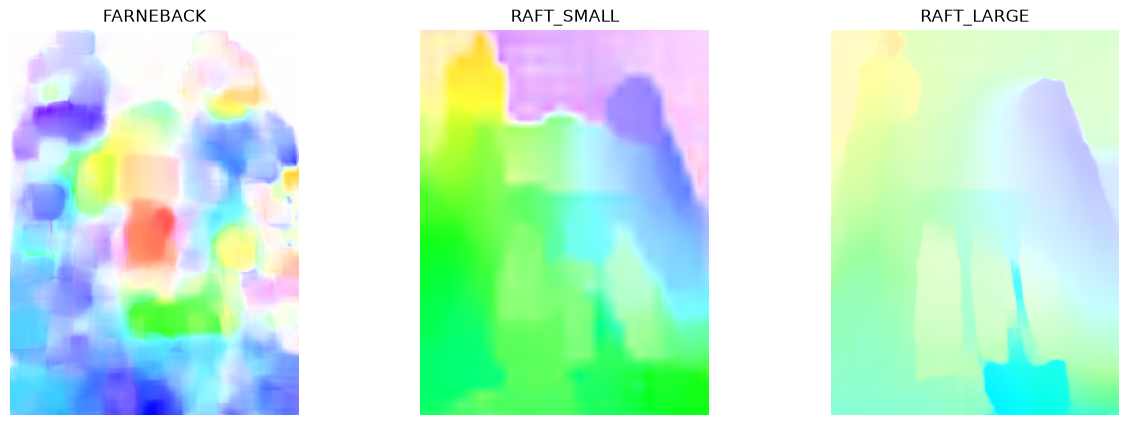

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, method in zip(axes, OpticalFlowMethod):
    pipeline = OpticalFlowPipeline(method)
    flow = pipeline.run_pipeline(image1, image2)
    ax.imshow(pipeline.flow_to_color(flow))
    ax.set_title(method.name)
    ax.axis('off')

## Dense registration

Warping the second image with the flow aligns it pixel by pixel with the first one, including regions that a single homography cannot align.

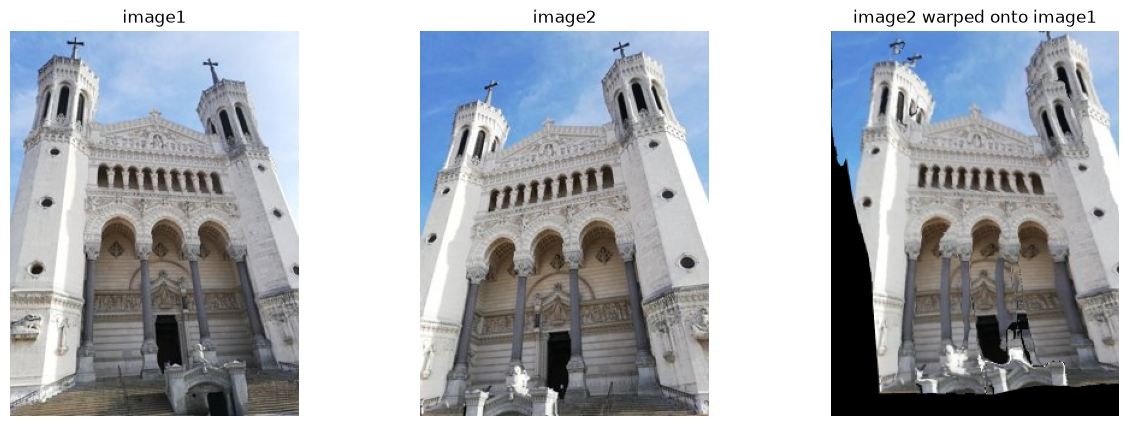

In [7]:
pipeline = OpticalFlowPipeline(OpticalFlowMethod.RAFT_LARGE)
flow = pipeline.run_pipeline(image1, image2)
warped = pipeline.warp(image2, flow)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, image) in zip(axes, [('image1', image1), ('image2', image2), ('image2 warped onto image1', warped)]):
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')